# 01. Data Understanding

## Project
Customer Behavioral Analysis and Churn Prediction for an E-commerce Platform

## Objective
Understand the structure, characteristics, and initial quality of the
customer churn dataset before performing data cleaning and modeling.

## Research Questions

- RQ1: Which customer groups have higher churn rates?
- RQ2: Which customer behaviors are associated with churn?
- RQ3: Can we predict customer churn?
- RQ4: Which factors contribute most to churn predictions?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [3]:
df = pd.read_csv(
    "D:/Desktop/Projects/customer-churn-analytics/data/raw/ecommerce_customer_churn_dataset.csv"
)

In [ ]:
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [20]:
df.shape

(50000, 25)

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  str    
 2   Country                        50000 non-null  str    
 3   City                           50000 non-null  str    
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null  float64
 1

In [22]:
df.dtypes

Age                              float64
Gender                               str
Country                              str
City                                 str
Membership_Years                 float64
Login_Frequency                  float64
Session_Duration_Avg             float64
Pages_Per_Session                float64
Cart_Abandonment_Rate            float64
Wishlist_Items                   float64
Total_Purchases                  float64
Average_Order_Value              float64
Days_Since_Last_Purchase         float64
Discount_Usage_Rate              float64
Returns_Rate                     float64
Email_Open_Rate                  float64
Customer_Service_Calls           float64
Product_Reviews_Written          float64
Social_Media_Engagement_Score    float64
Mobile_App_Usage                 float64
Payment_Method_Diversity         float64
Lifetime_Value                   float64
Credit_Balance                   float64
Churned                            int64
Signup_Quarter  

In [7]:
df.describe()

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
count,47505.000000,50000.000000,50000.000000,46601.000000,47000.000000,50000.000000,46000.000000,50000.000000,50000.000000,47000.000000,...,45509.000000,47472.000000,49832.000000,46500.000000,44000.000000,45000.000000,47500.000000,50000.000000,44500.000000,50000.000000
mean,37.802968,2.984009,11.624660,27.660754,8.737811,57.079973,4.298391,13.111576,123.117330,29.792872,...,6.680913,20.937980,5.681831,2.853312,29.364466,19.371607,2.353874,1440.626292,1966.233258,0.289000
std,11.834668,2.059105,7.810657,10.871013,3.778220,16.282723,3.189754,7.017312,175.569714,29.695062,...,6.143027,14.252561,2.676052,2.328948,20.574021,9.419252,1.110012,907.249443,1225.072166,0.453302
min,5.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,-13.000000,26.380000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,1.400000,6.000000,19.700000,6.000000,46.400000,2.000000,8.000000,87.050000,9.000000,...,2.900000,9.900000,4.000000,1.000000,13.200000,12.500000,2.000000,789.817500,1049.000000,0.000000
50%,38.000000,2.500000,11.000000,26.800000,8.400000,58.100000,4.000000,12.000000,112.970000,21.000000,...,5.400000,19.700000,5.000000,2.000000,27.600000,18.600000,2.000000,1243.415000,1896.000000,0.000000
75%,46.000000,4.000000,17.000000,34.700000,11.200000,68.700000,6.000000,17.000000,144.440000,41.000000,...,9.100000,30.400000,7.000000,4.000000,43.100000,25.500000,3.000000,1874.000000,2791.000000,1.000000
max,200.000000,10.000000,46.000000,75.600000,24.100000,143.743350,28.000000,128.700000,9666.379178,287.000000,...,99.615734,91.700000,21.000000,21.000000,100.000000,61.900000,5.000000,8987.240000,7197.000000,1.000000


In [8]:
missing = df.isnull().sum()

missing[missing > 0]

Age                              2495
Session_Duration_Avg             3399
Pages_Per_Session                3000
Wishlist_Items                   4000
Days_Since_Last_Purchase         3000
Discount_Usage_Rate              3500
Returns_Rate                     4491
Email_Open_Rate                  2528
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Credit_Balance                   5500
dtype: int64

In [9]:
missing_rate = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_rate[missing_rate > 0]

Social_Media_Engagement_Score    12.000
Credit_Balance                   11.000
Mobile_App_Usage                 10.000
Returns_Rate                      8.982
Wishlist_Items                    8.000
Product_Reviews_Written           7.000
Discount_Usage_Rate               7.000
Session_Duration_Avg              6.798
Pages_Per_Session                 6.000
Days_Since_Last_Purchase          6.000
Email_Open_Rate                   5.056
Payment_Method_Diversity          5.000
Age                               4.990
Customer_Service_Calls            0.336
dtype: float64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df[df.duplicated()].head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter


In [12]:
df["Churned"].value_counts()

Churned
0    35550
1    14450
Name: count, dtype: int64

In [13]:
df["Churned"].value_counts(normalize=True) * 100

Churned
0    71.1
1    28.9
Name: proportion, dtype: float64

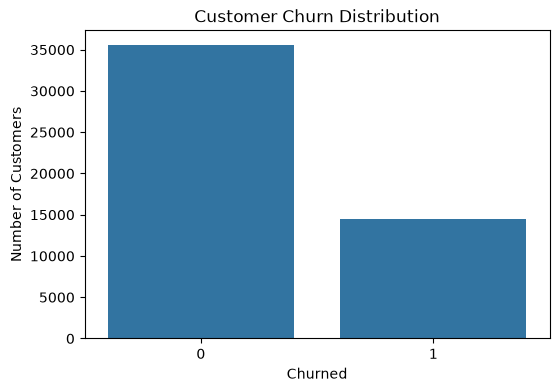

In [14]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churned")

plt.title("Customer Churn Distribution")
plt.xlabel("Churned")
plt.ylabel("Number of Customers")

plt.show()

In [15]:
categorical_cols = df.select_dtypes(
    include="object"
).columns

categorical_cols

C:\Users\PC\AppData\Local\Temp\ipykernel_12884\730935785.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(


Index(['Gender', 'Country', 'City', 'Signup_Quarter'], dtype='str')

In [16]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts().head(10))


Gender
Gender
Female    25116
Male      23947
Other       937
Name: count, dtype: int64

Country
Country
USA          17384
UK            7534
Canada        6023
Germany       4925
Australia     4061
France        4013
India         3512
Japan         2548
Name: count, dtype: int64

City
City
Houston        3549
Phoenix        3490
New York       3477
Chicago        3475
Los Angeles    3393
Manchester     1576
Birmingham     1535
Leeds          1529
London         1458
Glasgow        1436
Name: count, dtype: int64

Signup_Quarter
Signup_Quarter
Q3    12558
Q2    12521
Q4    12468
Q1    12453
Name: count, dtype: int64


In [17]:
numerical_cols = df.select_dtypes(
    include=np.number
).columns

numerical_cols

Index(['Age', 'Membership_Years', 'Login_Frequency', 'Session_Duration_Avg',
       'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items',
       'Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned'],
      dtype='str')

In [18]:
for col in numerical_cols:
    print(
        col,
        "min =", df[col].min(),
        "max =", df[col].max()
    )

Age min = 5.0 max = 200.0
Membership_Years min = 0.1 max = 10.0
Login_Frequency min = 0.0 max = 46.0
Session_Duration_Avg min = 1.0 max = 75.6
Pages_Per_Session min = 1.0 max = 24.1
Cart_Abandonment_Rate min = 0.0 max = 143.74335014288403
Wishlist_Items min = 0.0 max = 28.0
Total_Purchases min = -13.0 max = 128.70000000000002
Average_Order_Value min = 26.38 max = 9666.37917838422
Days_Since_Last_Purchase min = 0.0 max = 287.0
Discount_Usage_Rate min = 0.24 max = 116.64
Returns_Rate min = 0.0 max = 99.6157338622138
Email_Open_Rate min = 0.0 max = 91.7
Customer_Service_Calls min = 0.0 max = 21.0
Product_Reviews_Written min = 0.0 max = 21.0
Social_Media_Engagement_Score min = 0.0 max = 100.0
Mobile_App_Usage min = 0.0 max = 61.9
Payment_Method_Diversity min = 1.0 max = 5.0
Lifetime_Value min = 0.0 max = 8987.24
Credit_Balance min = 0.0 max = 7197.0
Churned min = 0 max = 1


## Initial Data Quality Assessment

### Dataset Structure
- Number of records: 50,000
- Number of features:  25
- Target variable: Churned

### Missing Values
- ...
  
### Duplicate Records
- ...

### Target Distribution
- Active customers: 71.1%
- Churned customers: 28.9%

### Categorical Features
- 4
### Numerical Features
- 21

### Initial Data Quality Issues
- ...